# 03 — Model Training & Comparison
**Fake News Detector** | Data Science Pipeline

Goals:
- Train 4 classifiers: Logistic Regression, Naive Bayes, Random Forest, Passive Aggressive
- Compare accuracy, precision, recall, F1-score
- Select the best model
- Save trained model and metadata

In [1]:
import sys, os, pickle, json
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Load Processed Data

In [2]:
with open('../data/processed/train_test_split.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../data/processed/vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

X_train = splits['X_train']
X_test  = splits['X_test']
y_train = splits['y_train']
y_test  = splits['y_test']

X_tr_tfidf = vectorizer.transform(X_train)
X_te_tfidf = vectorizer.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 172 | Test: 43


## 2. Train All Models

In [3]:
from src.models import train_all, pick_best

print('Training models...')
trained_models, results = train_all(X_tr_tfidf, y_train, X_te_tfidf, y_test)

for name, res in results.items():
    print(f'  {name:<25} accuracy={res["accuracy"]:.4f}')

Training models...


  Logistic Regression       accuracy=0.8605
  Naive Bayes               accuracy=0.8837
  Random Forest             accuracy=0.8372
  Passive Aggressive        accuracy=0.9070


/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


## 3. Accuracy Comparison

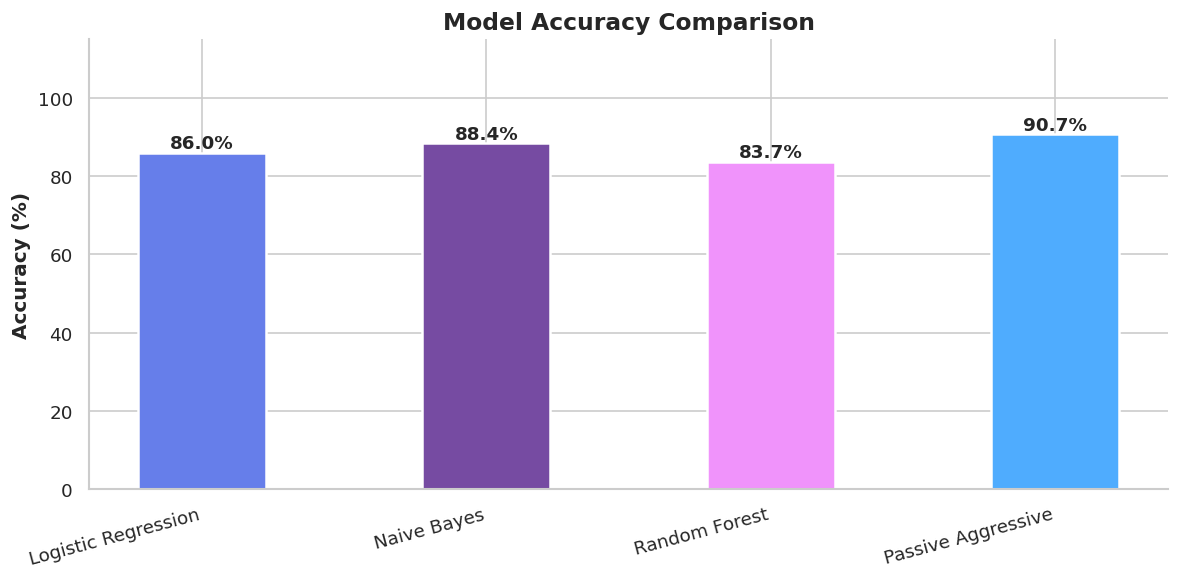

In [4]:
names = list(results.keys())
accs  = [results[m]['accuracy'] * 100 for m in names]
colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, color=colors, edgecolor='white', linewidth=1.5, width=0.45)
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', bbox_inches='tight')
plt.show()

## 4. Precision, Recall, F1 — All Models

In [5]:
metrics_rows = []
for name, res in results.items():
    r = res['report']
    metrics_rows.append({
        'Model':     name,
        'Accuracy':  round(res['accuracy'], 4),
        'Precision': round(r['weighted avg']['precision'], 4),
        'Recall':    round(r['weighted avg']['recall'], 4),
        'F1-Score':  round(r['weighted avg']['f1-score'], 4),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('F1-Score', ascending=False)
metrics_df.style.background_gradient(cmap='YlGn').format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Passive Aggressive,0.9070,0.9213,0.9070,0.9060
Naive Bayes,0.8837,0.8844,0.8837,0.8836
Logistic Regression,0.8605,0.8904,0.8605,0.8572
Random Forest,0.8372,0.8572,0.8372,0.8354


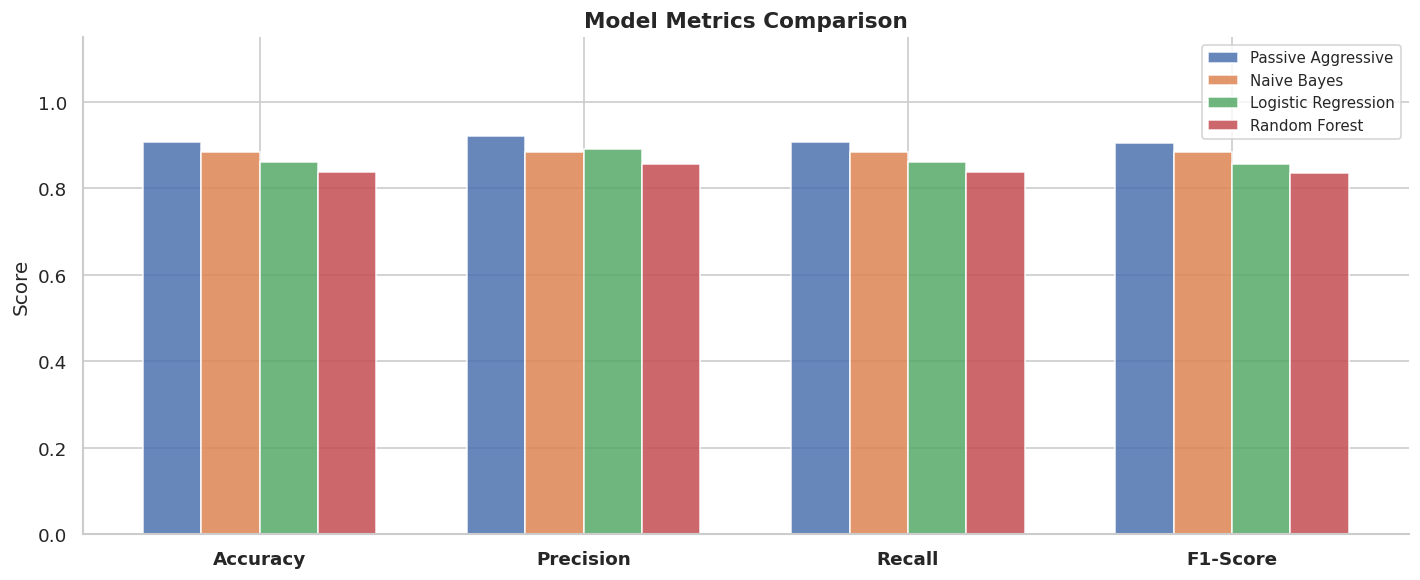

In [6]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metric_cols))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, row) in enumerate(metrics_df.iterrows()):
    vals = [row[c] for c in metric_cols]
    ax.bar(x + i*width, vals, width, label=model, alpha=0.85)

ax.set_xticks(x + width * (len(metrics_df)-1) / 2)
ax.set_xticklabels(metric_cols, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Metrics Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/metrics_comparison.png', bbox_inches='tight')
plt.show()

## 5. Best Model & Save

In [7]:
best_name, best_clf = pick_best(trained_models, results)
best_acc = results[best_name]['accuracy']

print(f'Best model : {best_name}')
print(f'Accuracy   : {best_acc:.4f}')

os.makedirs('../models', exist_ok=True)
with open('../models/fake_news_model.pkl', 'wb') as f:
    pickle.dump(best_clf, f, protocol=4)

metadata = {
    'best_model': best_name,
    'accuracy': round(best_acc, 4),
    'all_models': {k: {'accuracy': round(v['accuracy'], 4)} for k, v in results.items()},
    'vocab_size': int(len(vectorizer.get_feature_names_out())),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
}
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('\nSaved: models/fake_news_model.pkl')
print('Saved: models/model_metadata.json')

Best model : Passive Aggressive
Accuracy   : 0.9070

Saved: models/fake_news_model.pkl
Saved: models/model_metadata.json
